improved model accuracy:61.67%


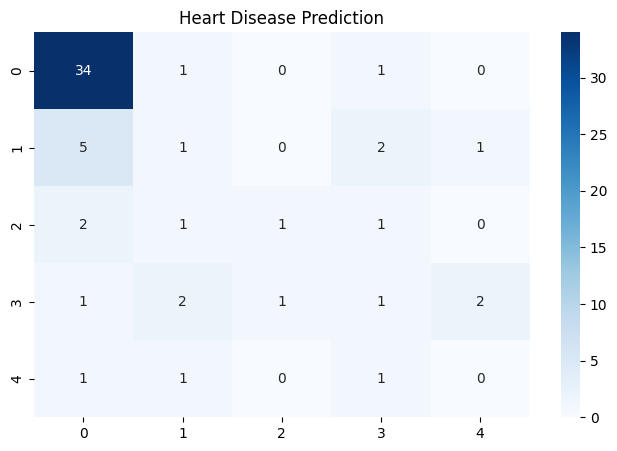

In [3]:
from ipywidgets.widgets.interaction import check_argspec
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#  Load and clean the data
url = "https://raw.githubusercontent.com/dataprofessor/data/master/heart-disease-cleveland.csv"
df = pd.read_csv(url)
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df = df.apply(pd.to_numeric)
df.rename(columns={df.columns[-1]: 'target'}, inplace=True)

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Feature Scaling (This improves accuracy and fixes the warning)
scaler = StandardScaler()
X_scaled =  scaler.fit_transform(X)

# Split the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.2, random_state=42)

#  Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

#  Evaluate
check = model.predict(X_test)
accuracy = accuracy_score(y_test, check)
print(f"improved model accuracy:{accuracy*100:.2f}%")

#  Final heatmap
plt.figure(figsize=(8,5))
sns.heatmap(confusion_matrix(y_test,check), annot = True,fmt = 'd', cmap= 'Blues')
plt.title('Heart Disease Prediction')
plt.show()